<a href="https://colab.research.google.com/github/KK-code001/Candidate-Screening-System/blob/main/XGboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Load data
df = pd.read_csv("ai_resume_screening (1).csv")

# Convert target column: Yes -> 1, No -> 0
df["shortlisted"] = df["shortlisted"].map({
    "Yes": 1,
    "No": 0
})

# Optional: remove this if still present in your dataset
if "skills_match_score" in df.columns:
    df = df.drop("skills_match_score", axis=1)

# One-hot encode education_level
df = pd.get_dummies(df, columns=["education_level"], drop_first=True)

# Features and target
X = df.drop("shortlisted", axis=1)
y = df["shortlisted"]

# Better split using stratify
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# XGBoost model
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    random_state=42,
    eval_metric="logloss"
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Full report
report_dict = classification_report(y_test, y_pred, output_dict=True)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8926666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.82      1807
           1       0.92      0.93      0.92      4193

    accuracy                           0.89      6000
   macro avg       0.88      0.87      0.87      6000
weighted avg       0.89      0.89      0.89      6000



In [ ]:
from sklearn.metrics import roc_auc_score

# Predict probabilities for the positive class
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc}")

ROC-AUC Score: 0.9580958909696254


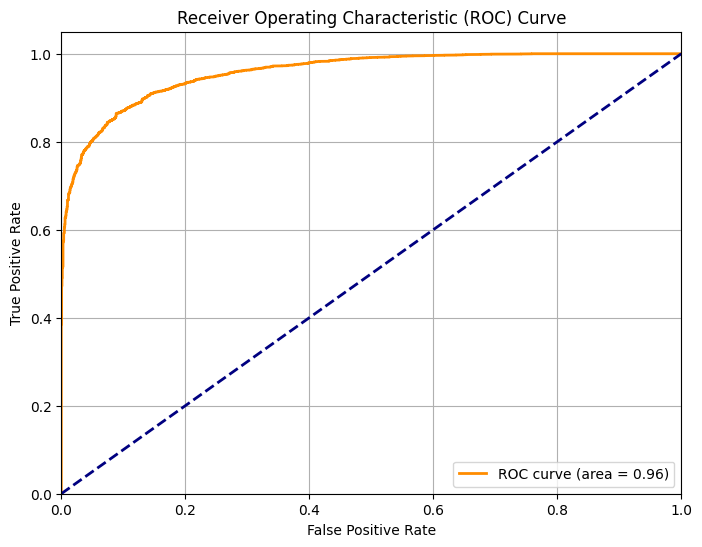

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Convert the classification report dictionary to a DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Save the DataFrame to a CSV file
report_csv_path = 'classification_report.csv'
report_df.to_csv(report_csv_path, index=True)

print(f"Classification report saved to {report_csv_path}")

Classification report saved to classification_report.csv


In [ ]:
from google.colab import files

# Download the generated CSV file
files.download('classification_report.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>